In [1]:
import sys
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Add the project root to Python path
project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
sys.path.append(str(project_root))

# ML toolbox imports
from ml_toolbox.data_loader import DatasetManager, DataLoader, create_windows_for_ml, extract_features_for_ml, FeatureConfig
from ml_toolbox.analysis.model_evaluation import evaluate_model_cv, cv_shap
from ml_toolbox.analysis import build_separability_report, cohens_d_summary

# Initialize dataset manager
dataset_path = project_root / "data_set"
dm = DatasetManager(dataset_path)

# Initialize data loader
data_loader = DataLoader(dataset_path)

# Load files (DataLoader supports multi-value filters)
data, metadata = data_loader.load_batch(
    sensor_type="current",
    frequency="20hz",
    loads=["no load"]
)

# Create windows
windows, labels, win_metadata = create_windows_for_ml(
    data_list=data,
    metadata_list=metadata,
    window_size=10000,
    max_windows_per_class=100,
    random_state=42
)

# Extract features
feature_conf = FeatureConfig.for_sensor("current")
feature_conf.time_domain = False
feature_conf.frequency_domain = False
feature_conf.hilbert_envelope = True
## feature_conf.set_family("cross_channel", params={"hilbert_envelope": False})
feature_conf.cross_channel = False
features, feature_names = extract_features_for_ml(
    windows, 
    metadata_list=win_metadata,
    feature_config=feature_conf
)

# Evaluate model
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    ))
])
eval_res = evaluate_model_cv(pipeline, features, labels)
shap_res = cv_shap(pipeline, features, labels)

# Class separability report
print("=== Cohen's d Class Separability ===")
separability_summary = cohens_d_summary(features, labels, feature_names)
separability_report = build_separability_report(separability_summary)
separability_report.head(20)

INFO:ml_toolbox.data_loader.data_loader:Loading 19 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 19 files
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 19 files
INFO:ml_toolbox.data_loader.windowing:Class 'faulty_bearing': selected 62 of 181 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'healthy': selected 62 of 62 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'misalignment': selected 62 of 185 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'system_misalignment': selected 62 of 164 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'faulty_bearing': selected 62 of 181 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'healthy': selected 62 of 62 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'misalignment': selected 62 of 185 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'system_misalignment': selected 62 of 164 available windows


Evaluating model (features: (248, 22), samples: 248)...
Mean CV Accuracy: 0.520 ± 0.023
Precision: 0.519, Recall: 0.520, F1: 0.513
Mean CV Accuracy: 0.520 ± 0.023
Precision: 0.519, Recall: 0.520, F1: 0.513
=== Cohen's d Class Separability ===
=== Cohen's d Class Separability ===


,feature,class_pair,d,mean_c1,mean_c2,std_c1,std_c2,feature_index,class_a,class_b,n_c1,n_c2,pair_index
0,load_under_load,0 vs 1,1.232060,0.435484,0.000000,0.499868,0.000000,21,0,1,62,62,0
1,ph_a_env_thd_power_frac,1 vs 2,1.118634,0.580538,0.530906,0.030991,0.054558,16,1,2,62,62,3
2,ph_a_env_fundamental_power_ratio,1 vs 2,0.992391,0.553220,0.507457,0.037092,0.053639,18,1,2,62,62,3
3,ph_a_env_thd_power_frac,1 vs 3,0.806190,0.580538,0.529605,0.030991,0.083799,16,1,3,62,62,4
4,ph_a_env_fundamental_power_ratio,1 vs 3,0.762796,0.553220,0.499189,0.037092,0.093052,18,1,3,62,62,4
5,ph_a_env_dom_rel_peak_power,1 vs 3,0.567684,0.916344,0.867659,0.032189,0.116936,12,1,3,62,62,4
6,ph_a_env_harmonic_count,2 vs 3,0.542118,3.161290,2.725806,0.833589,0.771827,19,2,3,62,62,5
7,ph_a_env_harmonic_ratio,1 vs 3,0.537091,0.962113,0.923173,0.022922,0.099937,17,1,3,62,62,4
8,load_under_load,2 vs 3,0.459833,0.612903,0.387097,0.491062,0.491062,21,2,3,62,62,5
9,ph_a_env_rms,0 vs 1,0.449127,0.031997,0.029636,0.005790,0.004664,0,0,1,62,62,0


In [ ]:
# SHAP Analysis Summary
import numpy as np

print("=== SHAP Analysis Summary ===")
num_folds = len(shap_res["shap_values_per_fold"])
print(f"Number of CV folds: {num_folds}")

# Check if multiclass or binary
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, 'shape') and len(first_shap.shape) == 3)

if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
    else:
        n_classes = first_shap.shape[2]
    print(f"Classification type: Multiclass ({n_classes} classes)")
    
    # Compute mean absolute SHAP values per feature per class across all folds
    mean_shap_per_class = []
    for class_idx in range(n_classes):
        if isinstance(first_shap, list):
            shap_vals_class = [fold["shap_values"][class_idx] for fold in shap_res["shap_values_per_fold"]]
        else:
            shap_vals_class = [fold["shap_values"][..., class_idx] for fold in shap_res["shap_values_per_fold"]]
        # Concatenate all validation samples across folds for this class
        all_shap_class = np.concatenate(shap_vals_class, axis=0)
        # Mean absolute SHAP value per feature for this class
        mean_abs_shap = np.mean(np.abs(all_shap_class), axis=0)
        mean_shap_per_class.append(mean_abs_shap)
    
    mean_shap_per_class = np.array(mean_shap_per_class)
    
else:
    print("Classification type: Binary")
    n_classes = 1
    # For binary classification, shap_values is a single array
    shap_vals = [fold["shap_values"] for fold in shap_res["shap_values_per_fold"]]
    all_shap = np.concatenate(shap_vals, axis=0)
    overall_importance = np.mean(np.abs(all_shap), axis=0)
    mean_shap_per_class = np.array([overall_importance])

# Get top 10 most important features per class
top_n = min(10, len(mean_shap_per_class[0]))

for class_idx in range(n_classes):
    print(f"\nTop {top_n} features for class {class_idx} by mean absolute SHAP value:")
    top_indices_class = np.argsort(mean_shap_per_class[class_idx])[::-1][:top_n]
    for i, idx in enumerate(top_indices_class):
        importance = mean_shap_per_class[class_idx][idx]
        feature_name = feature_names[idx]
        print(f"{i+1:2d}. {feature_name}: {importance:.4f}")

print(f"\nTotal features analyzed: {len(mean_shap_per_class[0])}")

=== SHAP Analysis Summary ===
Number of CV folds: 5
Classification type: Multiclass (3 classes)

Top 10 features for class 0 by mean absolute SHAP value:
 1. ph_a_env_flatness: 0.0417
 2. ph_a_env_crest_factor: 0.0319
 3. ph_a_env_kurtosis: 0.0264
 4. ph_a_env_spread: 0.0259
 5. ph_a_env_peak_sp_std: 0.0215
 6. ph_a_env_peak_freq_cv: 0.0206
 7. ph_a_env_centroid: 0.0157
 8. ph_a_env_ptp: 0.0155
 9. ph_a_env_form_factor: 0.0146
10. ph_a_env_rms: 0.0139

Top 10 features for class 1 by mean absolute SHAP value:
 1. ph_a_env_centroid: 0.0485
 2. ph_a_env_spread: 0.0412
 3. ph_a_env_form_factor: 0.0248
 4. ph_a_env_ptp: 0.0241
 5. ph_a_env_rms: 0.0219
 6. ph_a_env_peak_sp_std: 0.0163
 7. ph_a_env_flatness: 0.0160
 8. ph_a_env_peak_power_std: 0.0152
 9. ph_a_env_kurtosis: 0.0147
10. ph_a_env_crest_factor: 0.0146

Top 10 features for class 2 by mean absolute SHAP value:
 1. ph_a_env_spread: 0.0645
 2. ph_a_env_flatness: 0.0474
 3. ph_a_env_centroid: 0.0446
 4. ph_a_env_crest_factor: 0.0233
 5

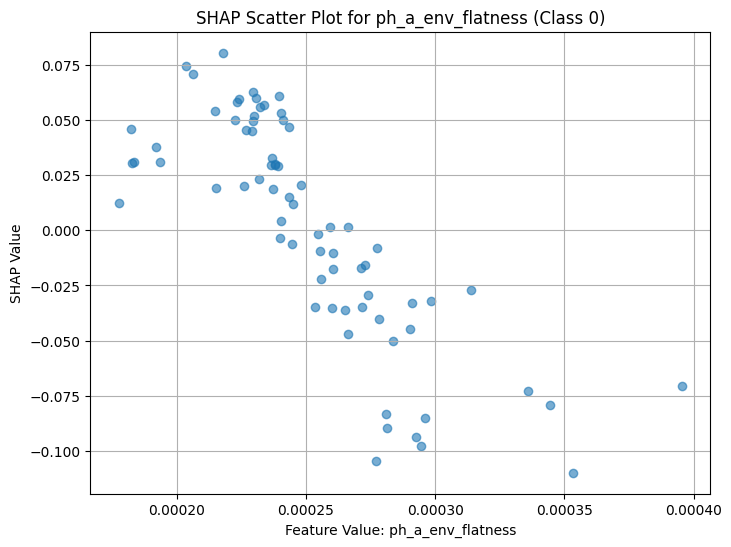

In [ ]:
# SHAP Scatter Plot for Top Feature of Class 0
import matplotlib.pyplot as plt

# Get top indices for class 0
top_n = min(10, len(mean_shap_per_class[0]))
top_indices = np.argsort(mean_shap_per_class[0])[::-1][:top_n]

# Check if multiclass
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, 'shape') and len(first_shap.shape) == 3)

# Get all validation SHAP values and features across folds for the top feature of class 0
if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
        all_shap_selected = np.concatenate([fold["shap_values"][0][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
    else:
        n_classes = first_shap.shape[2]
        all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0], 0] for fold in shap_res["shap_values_per_fold"]], axis=0)
else:
    all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)

all_X_selected = np.concatenate([features[fold["val_idx"], top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
feature_name_selected = feature_names[top_indices[0]]

# Plot scatter manually
plt.figure(figsize=(8, 6))
plt.scatter(x=all_X_selected, y=all_shap_selected, alpha=0.6)
plt.xlabel(f'Feature Value: {feature_name_selected}')
plt.ylabel('SHAP Value')
plt.title(f'SHAP Scatter Plot for {feature_name_selected} (Class 0)')
plt.grid(True)
plt.show()

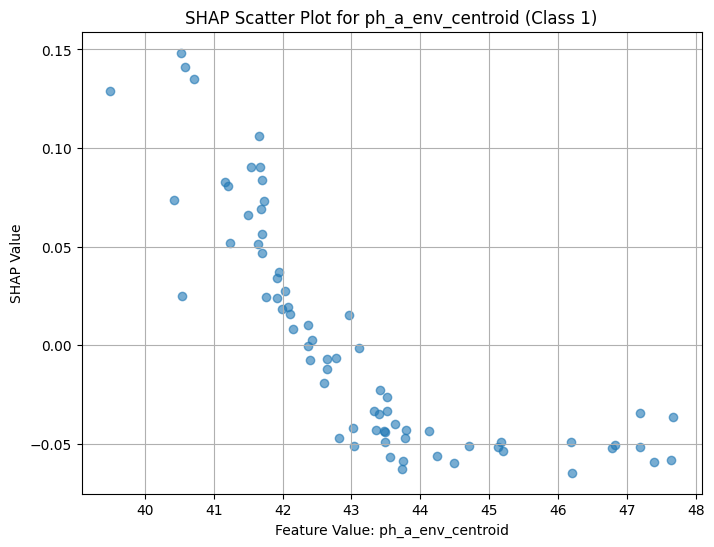

In [ ]:
# SHAP Scatter Plot for Top Feature of Class 1
import matplotlib.pyplot as plt

# Get top indices for class 1
class_idx = 1
top_n = min(10, len(mean_shap_per_class[class_idx]))
top_indices = np.argsort(mean_shap_per_class[class_idx])[::-1][:top_n]

# Check if multiclass
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, 'shape') and len(first_shap.shape) == 3)

# Get all validation SHAP values and features across folds for the top feature of class 1
if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
        all_shap_selected = np.concatenate([fold["shap_values"][class_idx][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
    else:
        n_classes = first_shap.shape[2]
        all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0], class_idx] for fold in shap_res["shap_values_per_fold"]], axis=0)
else:
    all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)

all_X_selected = np.concatenate([features[fold["val_idx"], top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
feature_name_selected = feature_names[top_indices[0]]

# Plot scatter manually
plt.figure(figsize=(8, 6))
plt.scatter(x=all_X_selected, y=all_shap_selected, alpha=0.6)
plt.xlabel(f'Feature Value: {feature_name_selected}')
plt.ylabel('SHAP Value')
plt.title(f'SHAP Scatter Plot for {feature_name_selected} (Class {class_idx})')
plt.grid(True)
plt.show()

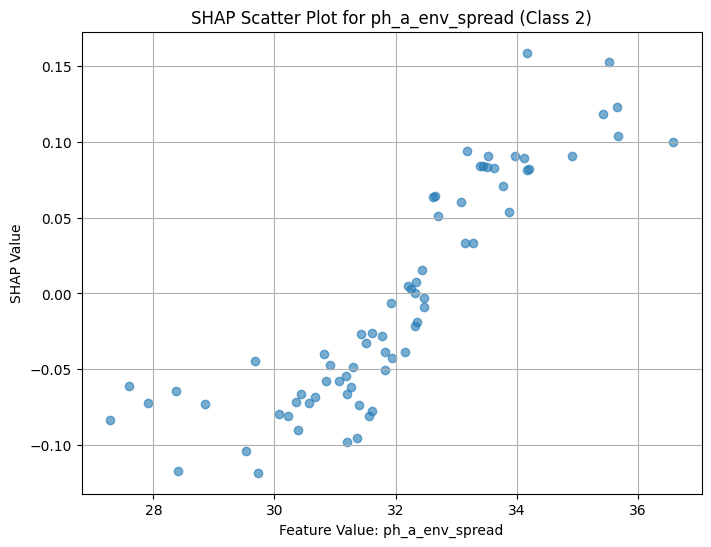

In [ ]:
# SHAP Scatter Plot for Top Feature of Class 2
import matplotlib.pyplot as plt

# Get top indices for class 2
class_idx = 2
top_n = min(10, len(mean_shap_per_class[class_idx]))
top_indices = np.argsort(mean_shap_per_class[class_idx])[::-1][:top_n]

# Check if multiclass
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, 'shape') and len(first_shap.shape) == 3)

# Get all validation SHAP values and features across folds for the top feature of class 2
if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
        all_shap_selected = np.concatenate([fold["shap_values"][class_idx][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
    else:
        n_classes = first_shap.shape[2]
        all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0], class_idx] for fold in shap_res["shap_values_per_fold"]], axis=0)
else:
    all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)

all_X_selected = np.concatenate([features[fold["val_idx"], top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
feature_name_selected = feature_names[top_indices[0]]

# Plot scatter manually
plt.figure(figsize=(8, 6))
plt.scatter(x=all_X_selected, y=all_shap_selected, alpha=0.6)
plt.xlabel(f'Feature Value: {feature_name_selected}')
plt.ylabel('SHAP Value')
plt.title(f'SHAP Scatter Plot for {feature_name_selected} (Class {class_idx})')
plt.grid(True)
plt.show()